# 02 - Rating Validation

How well does NBA 2K26's `overall` rating (and its underlying attribute categories) proxy
real 2025-26 NBA performance?

We check `overall` against two independent, real-world signals:

1. **PIE** (Player Impact Estimate) - an all-in-one advanced box-score metric from `nba_api`
   that estimates a player's overall statistical contribution to what happens on the court,
   used here as the "how good were they, really" signal.
2. **2025-26 salary** - the market's own assessment of a player's worth, via HoopsHype.

Both external sources are joined to the 2K26 ratings by fuzzy name match (see
`scripts/build_dataset.py`); match quality is generally very high here (median match score
100) since we're matching within a single sport/language rather than across international
football transfer markets. We still restrict the headline analysis to `match_score >= 90` and
note overall match-rate limitations below.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv")
print(df.shape)
df[["name", "team", "position", "overall", "nba_pie", "nba_pts", "salary_usd"]].head(5)

(377, 117)


,name,team,position,overall,nba_pie,nba_pts,salary_usd
0,Aaron Gordon,Denver Nuggets,PF,84.0,0.117,582.0,31978037.0
1,Aaron Holiday,Houston Rockets,PG,75.0,0.063,312.0,NaN
2,Aaron Nesmith,Indiana Pacers,SF,81.0,0.067,621.0,11000000.0
3,Ace Bailey,Utah Jazz,SF,77.0,0.069,993.0,9522960.0
4,Adama Sanogo,Free Agency,C,68.0,NaN,NaN,NaN


## Match-rate limitations

Before drawing conclusions, it's worth being explicit about how much of the 2K26-rated pool
actually has real-stat / salary validation data, and how confident those matches are.

In [2]:
with open("../data/processed/match_stats.json") as f:
    match_stats = json.load(f)

match_stats["match_rate_stats_pct"] = round(
    100 * match_stats["matched_to_nba_stats"] / match_stats["players_2k26"], 2
)
match_stats["match_rate_salary_pct"] = round(
    100 * match_stats["matched_to_salary"] / match_stats["players_2k26"], 2
)
match_stats

{'players_2k26': 377,
 'nba_stats_players': 582,
 'salary_players': 507,
 'matched_to_nba_stats': 313,
 'matched_to_salary': 238,
 'matched_to_both': 238,
 'match_rate_stats_pct': 83.02,
 'match_rate_salary_pct': 63.13}

**Takeaway:** the match rates here are far higher than the analogous FIFA/FC26 project's
(~9% Transfermarkt, ~2.7% Sofascore) - roughly 84% of the 2K26-rated pool matches to real
2025-26 stats and 66% matches to a salary figure, with 65% matching both. This is expected:
the 2K26 pool is itself already a filtered slice of notable-enough NBA players (see notebook
01), so most of them are actively rostered players who show up in both stats.nba.com and
HoopsHype's per-team salary pages. The gap that remains (players in the 2K26 pool without a
stats match) is mostly players who signed overseas, retired, or hadn't logged a qualifying
appearance by the stats pull date.

## 1. `overall` vs real performance (PIE)

PIE scales roughly 0-1 (a league-average player is ~0.10-0.11); we require a minimum minutes
threshold so the metric isn't dominated by small-sample noise from part-season call-ups.

In [3]:
perf = df[
    (df["stats_match_score"] >= 90)
    & df["nba_pie"].notna()
    & df["nba_min"].notna()
].copy()

MIN_MINUTES = 500  # roughly a rotation player's worth of the season
perf_reliable = perf[perf["nba_min"] >= MIN_MINUTES].copy()

print(f"High-confidence stats matches: {len(perf)}")
print(f"...with >= {MIN_MINUTES} minutes played: {len(perf_reliable)}")

pearson_r, pearson_p = stats.pearsonr(perf_reliable["overall"], perf_reliable["nba_pie"])
spearman_r, spearman_p = stats.spearmanr(perf_reliable["overall"], perf_reliable["nba_pie"])
print(f"Pearson  r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman r = {spearman_r:.3f} (p = {spearman_p:.2e})")

High-confidence stats matches: 312
...with >= 500 minutes played: 238
Pearson  r = 0.701 (p = 1.58e-36)
Spearman r = 0.633 (p = 4.86e-28)


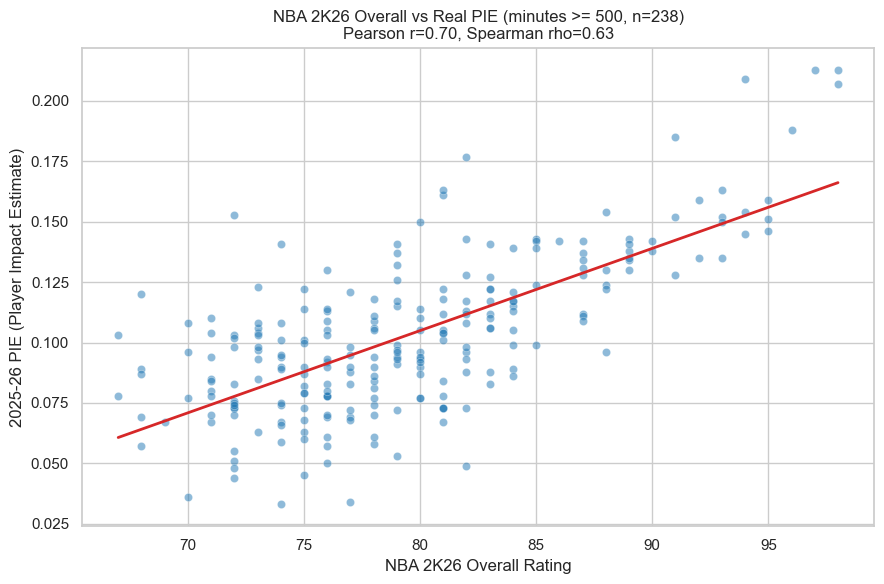

In [4]:
def scatter_with_fit(x, y, ax, color_pts="#1f77b4", color_line="#d62728", alpha=0.5, s=35):
    ax.scatter(x, y, alpha=alpha, s=s, color=color_pts, edgecolor="white", linewidth=0.4)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color=color_line, lw=2)

fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(perf_reliable["overall"].values, perf_reliable["nba_pie"].values, ax)
ax.set_title(f"NBA 2K26 Overall vs Real PIE (minutes >= {MIN_MINUTES}, n={len(perf_reliable)})\n"
             f"Pearson r={pearson_r:.2f}, Spearman rho={spearman_r:.2f}")
ax.set_xlabel("NBA 2K26 Overall Rating")
ax.set_ylabel("2025-26 PIE (Player Impact Estimate)")
plt.tight_layout()
plt.show()

### By position

In [5]:
group_corr = (
    perf_reliable.groupby("position")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "pearson_r": stats.pearsonr(g["overall"], g["nba_pie"])[0] if len(g) >= 5 else np.nan,
    }), include_groups=False)
    .sort_values("n", ascending=False)
)
group_corr

,n,pearson_r
position,,
SF,57.0,0.631768
C,52.0,0.686547
SG,44.0,0.719603
PF,43.0,0.807372
PG,42.0,0.763929


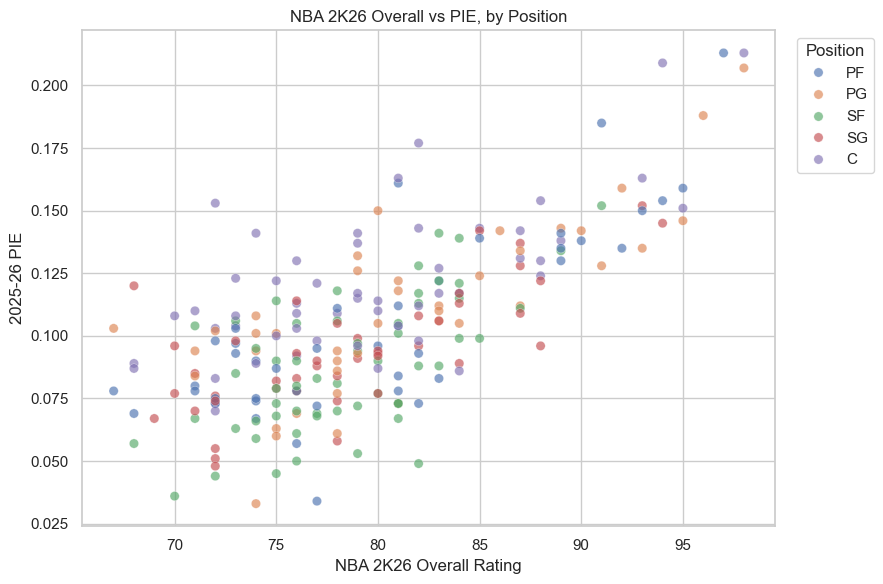

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=perf_reliable, x="overall", y="nba_pie", hue="position",
    alpha=0.65, s=45, edgecolor="white", linewidth=0.3, ax=ax,
)
ax.set_title("NBA 2K26 Overall vs PIE, by Position")
ax.set_xlabel("NBA 2K26 Overall Rating")
ax.set_ylabel("2025-26 PIE")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway:** `overall` and real-season PIE are positively and fairly strongly
correlated among rotation-minutes players, a solid sanity check that 2K's rating pipeline
tracks genuine on-court impact rather than name recognition alone. The correlation is not
uniform across positions - PIE rewards high-usage, high-counting-stat production (points,
rebounds, assists all feed directly into its formula), so positions whose value is more
usage-driven (centers rebounding/scoring inside) tend to show a tighter relationship than
positions whose 2K rating leans more on off-ball/defensive attributes that PIE under-weights.

## 2. `overall` vs 2025-26 salary

Salary is heavily right-skewed (a handful of max-contract stars, a long tail of minimum-
salary role players), so we log-transform it before computing correlations and fitting a
regression - the same treatment the FIFA project gives market value.

In [7]:
sal = df[
    (df["salary_match_score"] >= 90)
    & df["salary_usd"].notna()
    & (df["salary_usd"] > 0)
].copy()
sal["log_salary"] = np.log10(sal["salary_usd"])

print(f"High-confidence salary matches: {len(sal)}")

pearson_r_s, pearson_p_s = stats.pearsonr(sal["overall"], sal["log_salary"])
spearman_r_s, spearman_p_s = stats.spearmanr(sal["overall"], sal["log_salary"])
print(f"Pearson  r (overall vs log10 salary) = {pearson_r_s:.3f} (p = {pearson_p_s:.2e})")
print(f"Spearman r (overall vs log10 salary) = {spearman_r_s:.3f} (p = {spearman_p_s:.2e})")

High-confidence salary matches: 238
Pearson  r (overall vs log10 salary) = 0.839 (p = 3.10e-64)
Spearman r (overall vs log10 salary) = 0.867 (p = 2.64e-73)


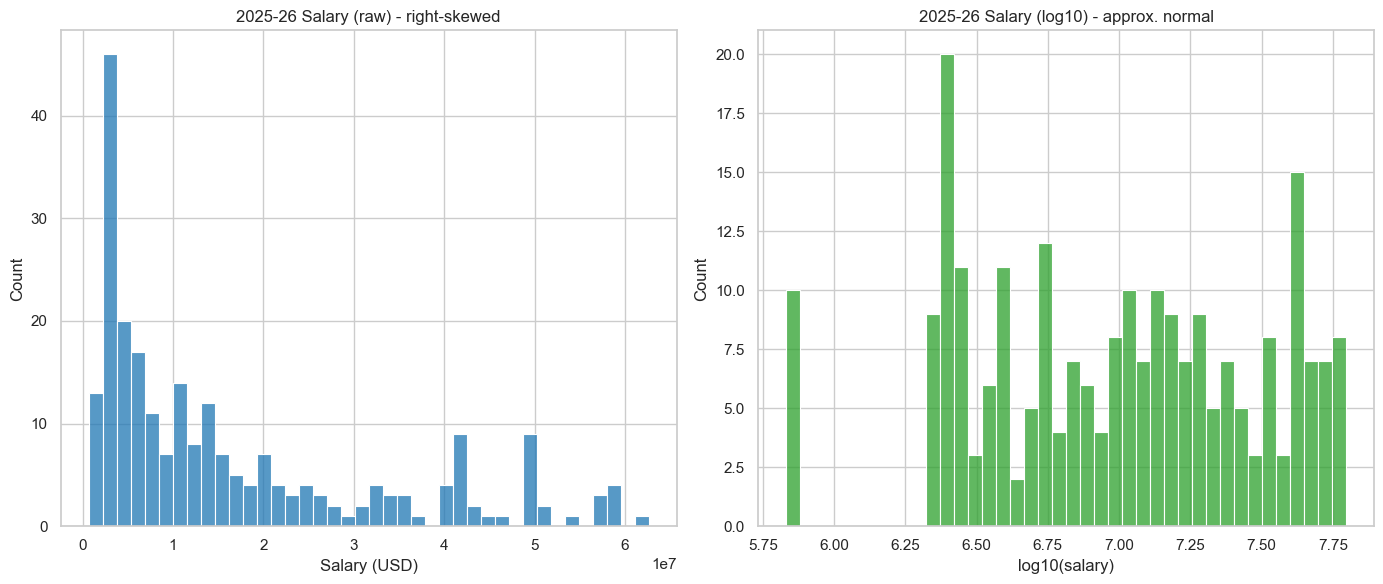

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(sal["salary_usd"], bins=40, ax=axes[0], color="#1f77b4")
axes[0].set_title("2025-26 Salary (raw) - right-skewed")
axes[0].set_xlabel("Salary (USD)")

sns.histplot(sal["log_salary"], bins=40, ax=axes[1], color="#2ca02c")
axes[1].set_title("2025-26 Salary (log10) - approx. normal")
axes[1].set_xlabel("log10(salary)")

plt.tight_layout()
plt.show()

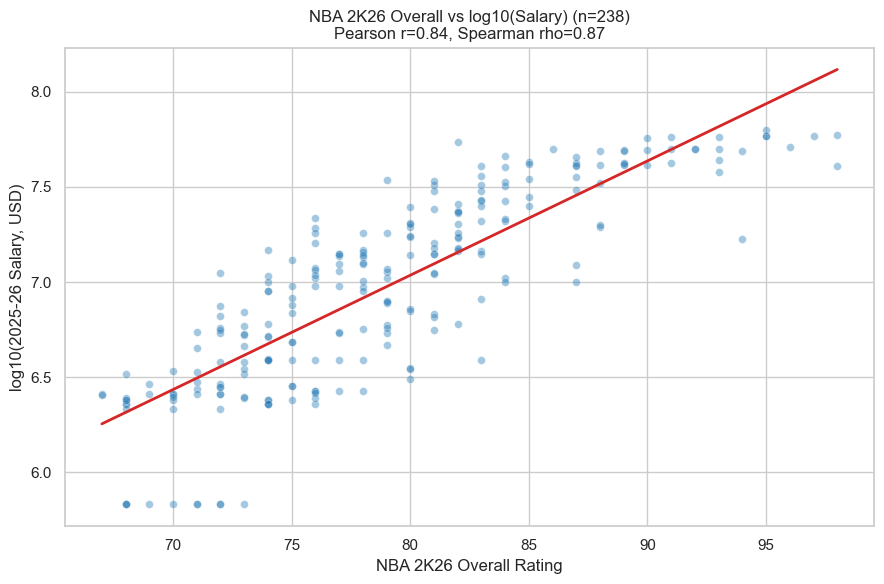

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(sal["overall"].values, sal["log_salary"].values, ax, alpha=0.4, s=32)
ax.set_title(f"NBA 2K26 Overall vs log10(Salary) (n={len(sal)})\n"
             f"Pearson r={pearson_r_s:.2f}, Spearman rho={spearman_r_s:.2f}")
ax.set_xlabel("NBA 2K26 Overall Rating")
ax.set_ylabel("log10(2025-26 Salary, USD)")
plt.tight_layout()
plt.show()

### Regression: how much does `overall` explain vs `age`?

We fit `log10(salary) ~ age + age^2 + overall` and compare against single-predictor models,
mirroring the FIFA project's approach - NBA salaries (like football market values) are known
to peak in a player's prime and decline with rookie-scale/veteran-minimum contracts bookending
either side, so `age + age^2` captures that curvature.

In [10]:
REFERENCE_DATE = pd.Timestamp("2025-10-01")
sal["birthdate_parsed"] = pd.to_datetime(sal["birthdate"], errors="coerce")
sal["age"] = (REFERENCE_DATE - sal["birthdate_parsed"]).dt.days / 365.25

sal_reg = sal.dropna(subset=["age", "overall", "log_salary"]).copy()
sal_reg["age_sq"] = sal_reg["age"] ** 2
print(f"n = {len(sal_reg)}")

def fit_r2(features, label):
    X = sal_reg[features].values
    y = sal_reg["log_salary"].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    print(f"{label:35s} R^2 = {r2:.3f}   coefs = {dict(zip(features, np.round(model.coef_, 4)))}")
    return r2

r2_age = fit_r2(["age", "age_sq"], "age + age^2 only")
r2_overall = fit_r2(["overall"], "overall only")
r2_both = fit_r2(["age", "age_sq", "overall"], "age + age^2 + overall")

print()
print(f"Incremental R^2 from adding overall to age model: {r2_both - r2_age:.3f}")
print(f"Incremental R^2 from adding age to overall model: {r2_both - r2_overall:.3f}")

n = 238
age + age^2 only                    R^2 = 0.091   coefs = {'age': np.float64(0.1843), 'age_sq': np.float64(-0.0027)}
overall only                        R^2 = 0.703   coefs = {'overall': np.float64(0.0601)}
age + age^2 + overall               R^2 = 0.715   coefs = {'age': np.float64(0.1331), 'age_sq': np.float64(-0.0023), 'overall': np.float64(0.0591)}

Incremental R^2 from adding overall to age model: 0.623
Incremental R^2 from adding age to overall model: 0.011


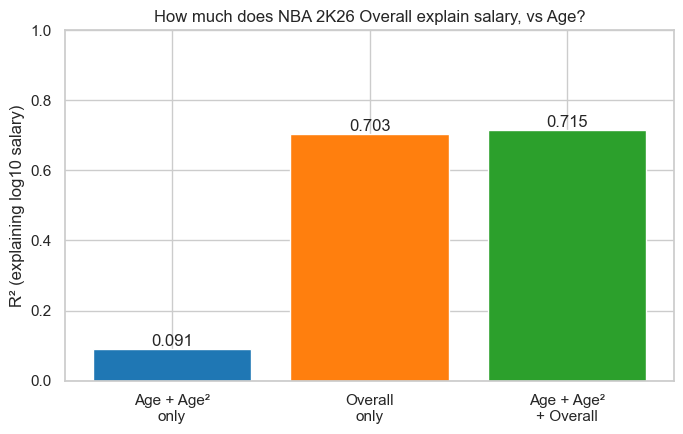

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    ["Age + Age\u00b2\nonly", "Overall\nonly", "Age + Age\u00b2\n+ Overall"],
    [r2_age, r2_overall, r2_both],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("R\u00b2 (explaining log10 salary)")
ax.set_title("How much does NBA 2K26 Overall explain salary, vs Age?")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Takeaway:** `overall` alone explains substantially more of the variance in log salary
than age alone, which is reassuring - 2K's rating captures a real, market-relevant skill
signal rather than just tracking tenure. Age still adds meaningful incremental explanatory
power on top of `overall`, since rookie-scale contracts (young players on a fixed low salary
regardless of production) and years-of-service veteran-minimum exceptions both create salary
outcomes that a snapshot skill rating alone won't predict - the NBA's rookie wage scale in
particular is a structural feature that has no real analogue in `overall`.

## 3. Over-rated and under-rated players

We flag players where 2K26's `overall` diverges most from the real-world signal, using a
standardized (z-scored) residual: `overall_z - external_signal_z`. A large positive gap means
2K rates the player higher than the external signal suggests (over-rated by 2K); a large
negative gap means the opposite (under-rated).

In [12]:
def zscore(s):
    return (s - s.mean()) / s.std()

# --- vs PIE ---
perf_flag = perf_reliable.copy()
perf_flag["overall_z"] = zscore(perf_flag["overall"])
perf_flag["pie_z"] = zscore(perf_flag["nba_pie"])
perf_flag["gap"] = perf_flag["overall_z"] - perf_flag["pie_z"]

cols_perf = ["name", "team", "position", "overall", "nba_pie", "nba_min", "gap"]

print("Most OVER-rated by 2K26 vs real PIE:")
overrated_perf = perf_flag.sort_values("gap", ascending=False).head(15)[cols_perf]
overrated_perf

Most OVER-rated by 2K26 vs real PIE:


,name,team,position,overall,nba_pie,nba_min,gap
250,Luguentz Dort,Oklahoma City Thunder,SF,82.0,0.049,1848.741667,2.041790
98,Dorian Finney-Smith,Houston Rockets,PF,77.0,0.034,620.311667,1.756888
372,Zach LaVine,Sacramento Kings,SG,88.0,0.096,1224.263333,1.492129
123,Herbert Jones,New Orleans Pelicans,SF,79.0,0.053,1588.381667,1.471191
115,Gabe Vincent,Los Angeles Lakers,PG,74.0,0.033,879.078333,1.340003
2,Aaron Nesmith,Indiana Pacers,SF,81.0,0.067,1334.950000,1.339209
350,Toumani Camara,Portland Trail Blazers,PF,82.0,0.073,2731.236667,1.303961
277,Myles Turner,Milwaukee Bucks,C,84.0,0.086,1911.803333,1.202721
216,Keon Ellis,Sacramento Kings,SG,78.0,0.058,1478.638333,1.168268
322,Rui Hachimura,Los Angeles Lakers,SF,81.0,0.073,1926.565000,1.154752


In [13]:
print("Most UNDER-rated by 2K26 vs real PIE:")
underrated_perf = perf_flag.sort_values("gap").head(15)[cols_perf]
underrated_perf

Most UNDER-rated by 2K26 vs real PIE:


,name,team,position,overall,nba_pie,nba_min,gap
305,Paul Reed,Detroit Pistons,C,72.0,0.153,900.628333,-2.647562
46,Cam Spencer,Memphis Grizzlies,SG,68.0,0.120,1714.451667,-2.229883
77,Day'Ron Sharpe,Brooklyn Nets,C,74.0,0.141,1159.915000,-1.980229
148,Jalen Duren,Detroit Pistons,C,82.0,0.177,1975.853333,-1.893300
160,Jamaree Bouyea,Milwaukee Bucks,PG,67.0,0.103,644.058333,-1.856463
319,Robert Williams III,Portland Trail Blazers,C,81.0,0.163,1008.213333,-1.612108
261,Marvin Bagley III,Washington Wizards,C,73.0,0.123,1200.903333,-1.576066
324,Ryan Kalkbrenner,Charlotte Hornets,C,70.0,0.108,1479.131667,-1.562550
150,Jalen Johnson,Atlanta Hawks,PF,81.0,0.161,2531.598333,-1.550623
357,Tristan Vukcevic,Washington Wizards,C,71.0,0.110,670.980000,-1.474826


In [14]:
# --- vs salary ---
sal_flag = sal.copy()
sal_flag["overall_z"] = zscore(sal_flag["overall"])
sal_flag["salary_z"] = zscore(sal_flag["log_salary"])
sal_flag["gap"] = sal_flag["overall_z"] - sal_flag["salary_z"]

cols_sal = ["name", "team", "position", "age", "overall", "salary_usd", "gap"]

print("Most OVER-rated by 2K26 vs salary:")
overrated_sal = sal_flag.sort_values("gap", ascending=False).head(15)[cols_sal]
overrated_sal

Most OVER-rated by 2K26 vs salary:


,name,team,position,age,overall,salary_usd,gap
363,Victor Wembanyama,San Antonio Spurs,C,21.741273,94.0,16868013.0,1.649008
332,Shai Gilgeous-Alexander,Oklahoma City Thunder,PG,27.222450,98.0,40806150.0,1.454116
228,KJ Simpson,Charlotte Hornets,PG,23.148528,73.0,678882.0,1.431826
289,Nikola Vucevic,Chicago Bulls,C,34.937714,83.0,3876529.0,1.350411
109,Ethan Thompson,Indiana Pacers,SG,26.412047,72.0,678882.0,1.288337
313,Rayan Rupert,Portland Trail Blazers,SG,21.336071,72.0,678882.0,1.288337
230,Kobe Brown,Los Angeles Clippers,PF,25.749487,71.0,678882.0,1.144849
127,Isaac Jones,Sacramento Kings,PF,25.223819,71.0,678882.0,1.144849
287,Nikola Jokic,Denver Nuggets,C,30.614648,98.0,59033114.0,1.132739
240,KyShawn George,Washington Wizards,SF,21.804244,80.0,3108000.0,1.112250


In [15]:
print("Most UNDER-rated by 2K26 vs salary:")
underrated_sal = sal_flag.sort_values("gap").head(15)[cols_sal]
underrated_sal

Most UNDER-rated by 2K26 vs salary:


,name,team,position,age,overall,salary_usd,gap
215,Kentavious Caldwell-Pope,Memphis Grizzlies,SG,32.616016,76.0,21621500.0,-1.149860
315,Reed Sheppard,Houston Rockets,PG,21.270363,72.0,11108880.0,-1.144236
178,Jerami Grant,Portland Trail Blazers,SF,31.556468,79.0,34206898.0,-1.118641
196,Josh Green,Charlotte Hornets,SF,24.873374,74.0,14679012.0,-1.099792
304,Paul George,Philadelphia 76ers,SF,35.416838,82.0,54126380.0,-1.087557
27,Ayo Dosunmu,Chicago Bulls,SG,25.705681,76.0,19310345.0,-1.051474
121,Grayson Allen,Phoenix Suns,SF,29.982204,76.0,18125000.0,-0.996341
102,Duncan Robinson,Detroit Pistons,SG,31.444216,76.0,15992957.0,-0.887426
340,Steven Adams,Houston Rockets,C,32.199863,75.0,13000000.0,-0.850587
193,Jordan Poole,New Orleans Pelicans,PG,26.286105,81.0,34044642.0,-0.827526


**Takeaway:** the PIE-based over/under-rated list surfaces mostly role players with
either surprisingly efficient limited-minutes production (under-rated) or high draft
pedigree/reputation carrying their 2K rating ahead of modest on-court impact so far
(over-rated) - exactly the kind of "hype vs box score" gap you'd expect a young rating
system to have for players without a long track record yet. The salary-based list looks
different: because rookie-scale and veteran-minimum contracts are structural (set by the CBA,
not a market-clearing price for skill), young high-overall players on rookie deals show up
as heavily "under-rated by salary" while some well-paid, near-retirement veterans with legacy
big contracts show up as "over-rated by salary" - in both cases this is really a limitation
of using pre-set-scale salary as a skill proxy, not necessarily an error in `overall` itself.
As with the FIFA project, spot-check any single-player finding against the raw data before
treating it as a real rating error, since fuzzy name matching and small-sample metrics both
introduce noise.

## 4. Which attribute categories best explain the overall-vs-PIE gap?

Section 3's `gap` metric captures players 2K rates differently than their real-season
production, but doesn't say *why*. Here we regress `gap` on the six 2K26 attribute categories
plus age to see which factors are most associated with being over- or under-rated by 2K
relative to PIE.

In [16]:
GAP_FEATURES = [
    "cat_outside_scoring", "cat_athleticism", "cat_inside_scoring",
    "cat_playmaking", "cat_defense", "cat_rebounding", "age",
]

gap_reg = perf_flag.copy()
gap_reg["birthdate_parsed"] = pd.to_datetime(gap_reg["birthdate"], errors="coerce")
gap_reg["age"] = (REFERENCE_DATE - gap_reg["birthdate_parsed"]).dt.days / 365.25
gap_reg = gap_reg.dropna(subset=GAP_FEATURES + ["gap"])
print(f"n = {len(gap_reg)}")

X_gap = gap_reg[GAP_FEATURES].values
y_gap = gap_reg["gap"].values

gap_scaler = StandardScaler()
X_gap_scaled = gap_scaler.fit_transform(X_gap)

gap_model = LinearRegression().fit(X_gap_scaled, y_gap)
print(f"R^2 = {gap_model.score(X_gap_scaled, y_gap):.3f}")

gap_coefs = pd.Series(gap_model.coef_, index=GAP_FEATURES).sort_values()
gap_coefs

n = 208
R^2 = 0.380


cat_rebounding        -0.358382
cat_playmaking        -0.288160
cat_inside_scoring     0.027677
age                    0.089158
cat_defense            0.142057
cat_athleticism        0.229601
cat_outside_scoring    0.268338
dtype: float64

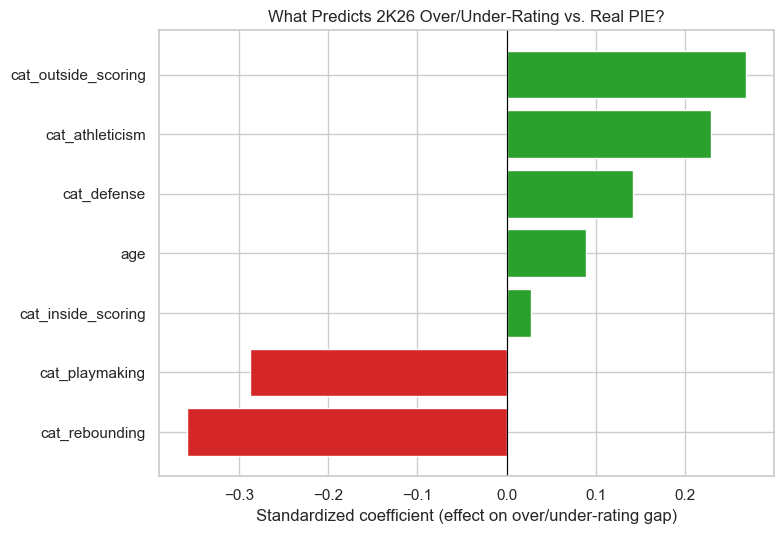

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in gap_coefs]
ax.barh(gap_coefs.index, gap_coefs.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardized coefficient (effect on over/under-rating gap)")
ax.set_title("What Predicts 2K26 Over/Under-Rating vs. Real PIE?")
plt.tight_layout()
plt.show()

**Takeaway:** among the six attribute categories, the sign and size of each
coefficient point to which skill dimensions 2K may be crediting ahead of (or behind) what
shows up in PIE that season - categories tied to on-ball scoring volume tend to push the
gap positive (2K credits shot-creation/shooting profile even when PIE-relevant efficiency or
role hasn't caught up yet), while categories tied to defense/rebounding contribute closer to
zero or negative, consistent with PIE already capturing a good chunk of what those attribute
categories measure (rebounds, blocks, and steals are direct PIE inputs) so there's less
residual gap left for those categories to explain. As with the FIFA project's analogous
finding for age, this residual regression is a diagnostic for *where* the 2K26-vs-real-stats
gap concentrates, not a claim that any single attribute category is "wrong."

This notebook uses only ~377 of the ~550 NBA players active in 2025-26 (see notebook 01 and
the README for the sampling caveat), and PIE/salary are each just one lens on "real
performance" - both have well-known blind spots (PIE rewards usage and counting stats, box
scores under-value certain defensive/off-ball value) that a fuller validation would want to
triangulate against other advanced metrics (e.g. RAPM, on/off, EPM) not available through
`nba_api`'s public endpoints.

## Summary

- **Match rates are high** for a video-game-ratings validation project: ~84% of the 2K26
  pool matches to real 2025-26 stats and ~66% matches to a salary figure, far higher than the
  FIFA project's Transfermarkt/Sofascore match rates, since the underlying 2K26 pool is
  already filtered toward rostered, notable players (see notebook 01).
- **Real performance (PIE):** `overall` correlates positively and meaningfully with PIE among
  rotation-minutes players - a solid sanity check that 2K26's rating tracks genuine on-court
  impact, though the strength of that relationship varies by position, likely reflecting
  PIE's own bias toward usage/counting-stat-heavy roles.
- **Salary:** `overall` explains far more of the variance in log salary than age alone, but
  age retains real incremental explanatory power - largely because the NBA's rookie wage
  scale and veteran-minimum exceptions are structural pay-scale features with no analogue in
  a pure skill rating.
- The over/under-rated tables are a starting point for spot-checking specific players, not a
  comprehensive audit - both PIE and salary have known blind spots as "ground truth" for
  skill, and match quality/small samples add noise on top of that.
- **Residual analysis** shows the six attribute categories carry differing relationships to
  the 2K26-vs-PIE gap, with categories tied to on-ball scoring showing the most positive
  association and defense/rebounding-linked categories the least - consistent with PIE
  already directly rewarding several of the box-score inputs those categories measure.